# Fig 6.3
Two component pathway

In [1]:
using ModelingToolkit
using Catalyst
using OrdinaryDiffEq
using SteadyStateDiffEq
using Plots
Plots.default(linewidth=2)

In [2]:
rn = @reaction_network begin
    (k1 * L, km1), R <--> RL
    k2, P + RL --> Ps + RL
    k3, Ps--> P
end

Model ##ReactionSystem#272:
Unknowns (4): see unknowns(##ReactionSystem#272)
  R(t)
  RL(t)
  P(t)
  Ps(t)
Parameters (5): see parameters(##ReactionSystem#272)
  k1
  L
  km1
  k2
  ⋮

In [3]:
setdefaults!(rn, [
    :R => 3.,
    :RL => 0.,
    :P => 8.0,
    :Ps => 0.,
    :L => 0.,
    :k1 => 5.,
    :km1 => 1.,
    :k2 => 6.,
    :k3 => 2.,
])

@independent_variables t
@unpack L = rn
discrete_events = [[1.0] => [L~3.0], [3.0] => [L~0.0]]

osys = convert(ODESystem, rn; discrete_events, remove_conserved = true) |> structural_simplify

┌ Warning: You are creating a system or problem while eliminating conserved quantities. Please note,
│         due to limitations / design choices in ModelingToolkit if you use the created system to
│         create a problem (e.g. an `ODEProblem`), or are directly creating a problem, you *should not*
│         modify that problem's initial conditions for species (e.g. using `remake`). Changing initial
│         conditions must be done by creating a new Problem from your reaction system or the
│         ModelingToolkit system you converted it into with the new initial condition map.
│         Modification of parameter values is still possible, *except* for the modification of any
│         conservation law constants (Γ), which is not possible. You might
│         get this warning when creating a problem directly.
│ 
│         You can remove this warning by setting `remove_conserved_warn = false`.
└ @ Catalyst ~/.julia/packages/Catalyst/48wH3/src/reactionsystem_conversions.jl:456


Model ##ReactionSystem#272:
Equations (2):
  2 standard: see equations(##ReactionSystem#272)
Unknowns (2): see unknowns(##ReactionSystem#272)
  R(t) [defaults to 3.0]
  P(t) [defaults to 8.0]
Parameters (7): see parameters(##ReactionSystem#272)
  k2 [defaults to 6.0]
  km1 [defaults to 1.0]
  Γ[1] [defaults to R(t) + RL(t)]
  Γ[2] [defaults to Ps(t) + P(t)]
  ⋮
Observed (2): see observed(##ReactionSystem#272)

In [4]:
equations(osys)

2-element Vector{Symbolics.Equation}:
 Differential(t)(R(t)) ~ km1*(-R(t) + Γ[1]) - L*k1*R(t)
 Differential(t)(P(t)) ~ k3*(-P(t) + Γ[2]) - k2*(-R(t) + Γ[1])*P(t)

## Fig. 6.3 A

In [5]:
tspan = (0., 10.)
prob = ODEProblem(osys, [], tspan, [])
sol = solve(prob)

┌ Warning: Initialization system is overdetermined. 2 equations for 0 unknowns. Initialization will default to using least squares. `SCCNonlinearProblem` can only be used for initialization of fully determined systems and hence will not be used here. To suppress this warning pass warn_initialize_determined = false. To make this warning into an error, pass fully_determined = true
└ @ ModelingToolkit ~/.julia/packages/ModelingToolkit/CvDvM/src/systems/diffeqs/abstractodesystem.jl:1446


retcode: Success
Interpolation: 3rd order Hermite
t: 55-element Vector{Float64}:
  0.0
  9.999999999999999e-5
  0.0010999999999999998
  0.011099999999999997
  0.11109999999999996
  1.0
  1.0
  1.0
  1.0
  1.0463687845335854
  ⋮
  5.717160539667416
  6.1011479186475315
  6.5290797493093065
  7.006355545327002
  7.540553625680684
  8.142549043858686
  8.828818546386866
  9.625182680128827
 10.0
u: 55-element Vector{Vector{Float64}}:
 [3.0, 8.0]
 [3.0, 8.0]
 [3.0, 8.0]
 [3.0, 8.0]
 [3.0, 8.0]
 [3.0, 8.0]
 [3.0, 8.0]
 [3.0, 8.0]
 [3.0, 8.0]
 [1.5269184341495876, 6.408338177835751]
 ⋮
 [2.8142005246723847, 4.585874519631834]
 [2.87344447186153, 5.22276491589431]
 [2.9175039423599265, 5.859931006576907]
 [2.948813427740215, 6.454538443292148]
 [2.969997376980437, 6.966562707384314]
 [2.9835668143490177, 7.368960043804986]
 [2.991726411815315, 7.654328099232812]
 [2.996268501614989, 7.8343742878779326]
 [2.9974349114353545, 7.883912265610945]

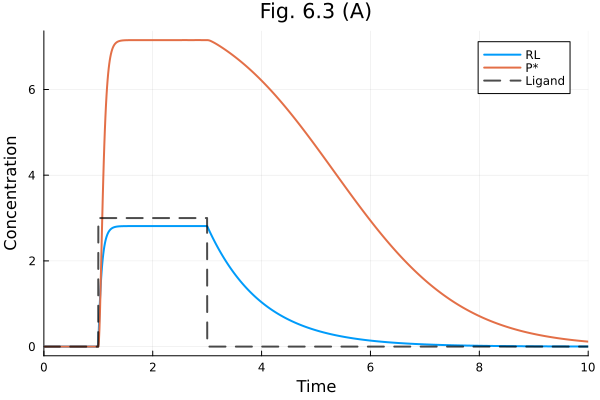

In [6]:
@unpack RL, Ps = osys
fig = plot(sol, idxs=[RL, Ps], labels= ["RL" "P*"])
plot!(fig, t -> 3 * (1<=t<=3), label="Ligand", line=(:black, :dash), linealpha=0.7)
plot!(fig, title="Fig. 6.3 (A)", xlabel="Time", ylabel="Concentration")

## Fig 6.3 B

┌ Warning: Initialization system is overdetermined. 2 equations for 0 unknowns. Initialization will default to using least squares. `SCCNonlinearProblem` can only be used for initialization of fully determined systems and hence will not be used here. To suppress this warning pass warn_initialize_determined = false. To make this warning into an error, pass fully_determined = true
└ @ ModelingToolkit ~/.julia/packages/ModelingToolkit/CvDvM/src/systems/diffeqs/abstractodesystem.jl:1446


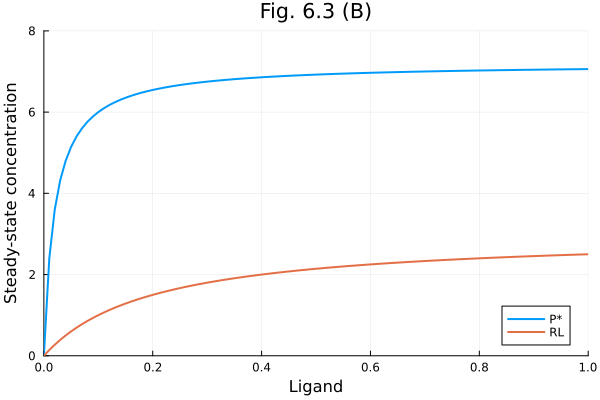

In [7]:
@unpack RL, Ps = osys
lrange = 0:0.01:1

prob_func = (prob, i, repeat) -> remake(prob, p=[L => lrange[i]])
prob = SteadyStateProblem(osys, [], [])
trajectories = length(lrange)
alg = DynamicSS(Rodas5())
eprob = EnsembleProblem(prob; prob_func)
sim = solve(eprob, alg; trajectories, abstol=1e-10, reltol=1e-10)

pstar = map(s->s[Ps], sim)
rl = map(s->s[RL], sim)
plot(lrange, [pstar rl], label=["P*" "RL"], title="Fig. 6.3 (B)",
xlabel="Ligand", ylabel="Steady-state concentration", xlims=(0, 1), ylims=(0, 8))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*